Purpose: Look at the results of differential expression between each parental species and the relevant subgenome in *Y. gloriosa*. Integrate with Yg HEB results to identify motif enrichment target genes.<br>
Author: Anna Pardo<br>
Date initiated: Feb. 5, 2026

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

In [3]:
datadir = "/home/leviathan22/Yucca_genomics/rna_insilico_genome/counts/"

In [4]:
yadegs = pd.read_csv(os.path.join(datadir,"DESeqres_Ya_v_YgYasubg.txt"),sep="\t",header="infer")
yfdegs = pd.read_csv(os.path.join(datadir,"DESeqres_Yf_v_YgYfsubg.txt"),sep="\t",header="infer")

In [6]:
# load CAM gene annotation - will be needed later
cam = pd.read_csv(os.path.join("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/",
                              "camgenes_Ya_Yf_orthology_synteny.txt"),sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [5]:
# load HEB results
heb = pd.read_csv(os.path.join("/home/leviathan22/Yucca_genomics/rna_insilico_genome/heb_deseq_outfiles/",
                               "deseq_HEB_with_additional_cols.txt"),sep="\t",header="infer")
heb.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,subgenome_bias
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,Yf
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,Yf
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,Yf
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,19,Yf
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,15,Yf


In [7]:
yadegs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,599.768106,0.277119,0.068780,4.029050,5.600264e-05,1.490326e-04,Yucal.01G000100.v2.1,aloifolia-V-18
1,62.040930,-0.560176,0.064631,-8.667243,4.427109e-18,3.940780e-17,Yucal.01G000200.v2.1,aloifolia-V-18
2,87.607801,-0.299740,0.060856,-4.925414,8.418210e-07,2.823562e-06,Yucal.01G000600.v2.1,aloifolia-V-18
3,55.677109,-0.249716,0.077282,-3.231231,1.232584e-03,2.690041e-03,Yucal.01G000700.v2.1,aloifolia-V-18
4,194.610942,0.313781,0.061659,5.088986,3.599837e-07,1.262833e-06,Yucal.01G000900.v2.1,aloifolia-V-18


In [8]:
# first: make a basic plot of how many DEGs from parents there are for each genotype of Yg
## make a regulation column (aka generational bias - parent is always the reference)

yareg = []
for i in list(yadegs["log2FoldChange"]):
    if i>0:
        yareg.append("Up")
    elif i<0:
        yareg.append("Down")
yadegs["reg"] = yareg

In [9]:
yfreg = []
for i in list(yfdegs["log2FoldChange"]):
    if i>0:
        yfreg.append("Up")
    elif i<0:
        yfreg.append("Down")
yfdegs["reg"] = yfreg

In [10]:
# now set up a genotype column for each
yagts = {}
for i in yadegs["Contrast"].unique():
    yagts[i] = i.split("-")[2]
yadegs["Genotype"] = yadegs["Contrast"].map(yagts)
yadegs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,reg,Genotype
0,599.768106,0.277119,0.068780,4.029050,5.600264e-05,1.490326e-04,Yucal.01G000100.v2.1,aloifolia-V-18,Up,18
1,62.040930,-0.560176,0.064631,-8.667243,4.427109e-18,3.940780e-17,Yucal.01G000200.v2.1,aloifolia-V-18,Down,18
2,87.607801,-0.299740,0.060856,-4.925414,8.418210e-07,2.823562e-06,Yucal.01G000600.v2.1,aloifolia-V-18,Down,18
3,55.677109,-0.249716,0.077282,-3.231231,1.232584e-03,2.690041e-03,Yucal.01G000700.v2.1,aloifolia-V-18,Down,18
4,194.610942,0.313781,0.061659,5.088986,3.599837e-07,1.262833e-06,Yucal.01G000900.v2.1,aloifolia-V-18,Up,18


In [11]:
yfgts = {}
for i in yfdegs["Contrast"].unique():
    yfgts[i] = i.split("-")[2]
yfdegs["Genotype"] = yfdegs["Contrast"].map(yfgts)

In [14]:
yasum = yadegs.groupby(["Genotype","reg"]).count()["baseMean"].reset_index().rename(columns={"baseMean":"n_genes"})

In [15]:
yfsum = yfdegs.groupby(["Genotype","reg"]).count()["baseMean"].reset_index().rename(columns={"baseMean":"n_genes"})

In [16]:
yasum["Parental Species"] = "aloifolia"
yfsum["Parental Species"] = "filamentosa"

In [17]:
yasum.head()

,Genotype,reg,n_genes,Parental Species
0,12,Down,9959,aloifolia
1,12,Up,9887,aloifolia
2,13,Down,8529,aloifolia
3,13,Up,11681,aloifolia
4,15,Down,8994,aloifolia


In [18]:
totalsum = pd.concat([yasum,yfsum])

In [20]:
totalsum["parent_reg"] = totalsum["Parental Species"]+"_"+totalsum["reg"]

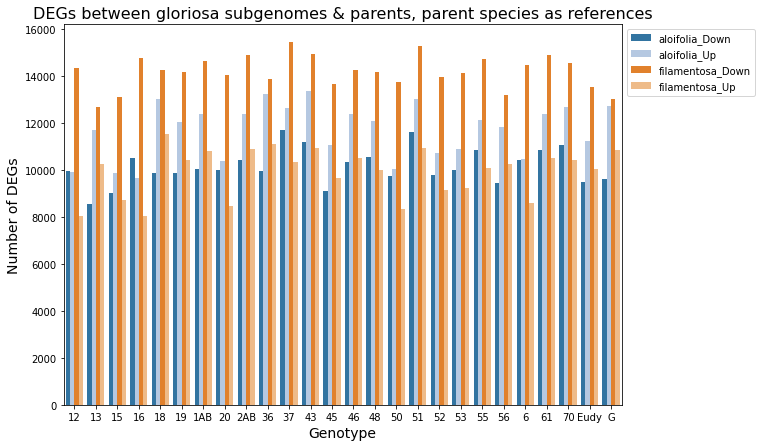

In [28]:
# make a bar chart
fig,ax = plt.subplots(figsize=(10,7))
sns.barplot(data=totalsum,x="Genotype",y="n_genes",hue="parent_reg",palette="tab20")
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel("Number of DEGs",fontsize=14)
plt.xlabel("Genotype",fontsize=14)
plt.title("DEGs between gloriosa subgenomes & parents, parent species as references",fontsize=16)
plt.savefig("./parents_Yg_degs_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./parents_Yg_degs_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./parents_Yg_degs_summary.svg",dpi=200,bbox_inches="tight")

## Compare with HEB results: what's the overlap?

In [29]:
heb.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,subgenome_bias
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,Yf
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,Yf
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,Yf
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,19,Yf
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,15,Yf


In [64]:
# start for Ya data
yahebgenes = heb[["Ya_GeneID","genotype","subgenome_bias","syntelogID"]].rename(columns={"genotype":"Genotype","Ya_GeneID":"GeneID"})
yahebgenes.head()

,GeneID,Genotype,subgenome_bias,syntelogID
0,Yucal.01G000200.v2.1,18,Yf,recip_syn2
1,Yucal.01G000200.v2.1,2AB,Yf,recip_syn2
2,Yucal.01G000200.v2.1,1AB,Yf,recip_syn2
3,Yucal.01G000200.v2.1,19,Yf,recip_syn2
4,Yucal.01G000200.v2.1,15,Yf,recip_syn2


In [31]:
yadegs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,reg,Genotype
0,599.768106,0.277119,0.068780,4.029050,5.600264e-05,1.490326e-04,Yucal.01G000100.v2.1,aloifolia-V-18,Up,18
1,62.040930,-0.560176,0.064631,-8.667243,4.427109e-18,3.940780e-17,Yucal.01G000200.v2.1,aloifolia-V-18,Down,18
2,87.607801,-0.299740,0.060856,-4.925414,8.418210e-07,2.823562e-06,Yucal.01G000600.v2.1,aloifolia-V-18,Down,18
3,55.677109,-0.249716,0.077282,-3.231231,1.232584e-03,2.690041e-03,Yucal.01G000700.v2.1,aloifolia-V-18,Down,18
4,194.610942,0.313781,0.061659,5.088986,3.599837e-07,1.262833e-06,Yucal.01G000900.v2.1,aloifolia-V-18,Up,18


In [65]:
ya_degs_heb = yahebgenes.merge(yadegs[["GeneID","Genotype","reg"]])
ya_degs_heb.rename(columns={"reg":"DE_v_Ya"},inplace=True)
ya_degs_heb.head()

,GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Ya
0,Yucal.01G000200.v2.1,18,Yf,recip_syn2,Down
1,Yucal.01G000200.v2.1,2AB,Yf,recip_syn2,Down
2,Yucal.01G000200.v2.1,1AB,Yf,recip_syn2,Down
3,Yucal.01G000200.v2.1,19,Yf,recip_syn2,Down
4,Yucal.01G000200.v2.1,15,Yf,recip_syn2,Down


In [66]:
yfhebgenes = heb[["Yf_GeneID","genotype","subgenome_bias","syntelogID"]].rename(columns={"genotype":"Genotype","Yf_GeneID":"GeneID"})
yf_degs_heb = yfhebgenes.merge(yfdegs[["GeneID","Genotype","reg"]])
yf_degs_heb.rename(columns={"reg":"DE_v_Yf"},inplace=True)
yf_degs_heb.head()

,GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Yf
0,YufilH1000007m.g,2AB,Yf,recip_syn2,Down
1,YufilH1000007m.g,1AB,Yf,recip_syn2,Down
2,YufilH1000007m.g,19,Yf,recip_syn2,Up
3,YufilH1000007m.g,Eudy,Yf,recip_syn2,Up
4,YufilH1000007m.g,56,Yf,recip_syn2,Up


In [45]:
ya_sum = ya_degs_heb.groupby(["Genotype","subgenome_bias","DE_v_Ya"]).count().rename(columns={"GeneID":"n_genes"}).reset_index()
ya_sum["bias_DE"] = ya_sum["subgenome_bias"]+"_DE"+ya_sum["DE_v_Ya"]
ya_sum.head()

,Genotype,subgenome_bias,DE_v_Ya,n_genes,bias_DE
0,13,Ya,Down,1864,Ya_DEDown
1,13,Ya,Up,3281,Ya_DEUp
2,13,Yf,Down,2687,Yf_DEDown
3,13,Yf,Up,2358,Yf_DEUp
4,15,Ya,Down,1460,Ya_DEDown


In [44]:
yf_sum = yf_degs_heb.groupby(["Genotype","subgenome_bias","DE_v_Yf"]).count().rename(columns={"GeneID":"n_genes"}).reset_index()
yf_sum["bias_DE"] = yf_sum["subgenome_bias"]+"_DE"+yf_sum["DE_v_Yf"]

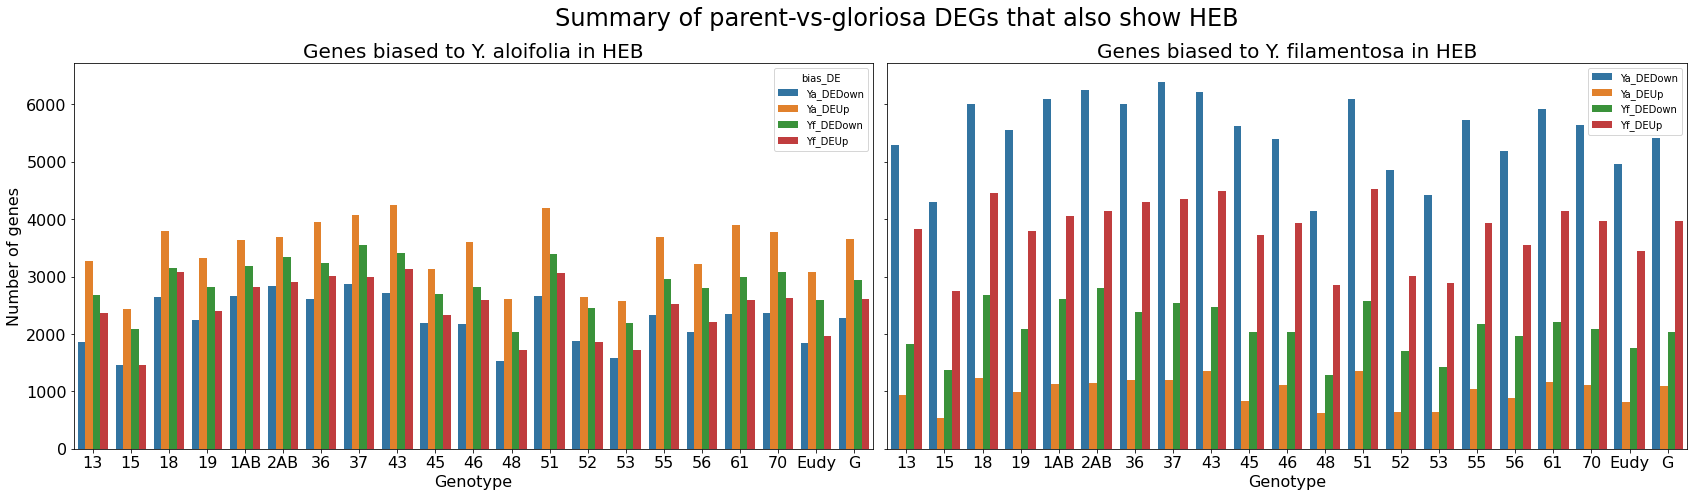

In [79]:
# visualize
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(25,7),sharey=True)

sns.barplot(ax=ax[0],data=ya_sum,x="Genotype",y="n_genes",hue="bias_DE")
sns.barplot(ax=ax[1],data=yf_sum,x="Genotype",y="n_genes",hue="bias_DE")
plt.legend(bbox_to_anchor=(1,1))

plt.ylabel("")
ax[0].set_ylabel("Number of genes",fontsize=16)
ax[0].set_xlabel("Genotype",fontsize=16)
ax[1].set_xlabel("Genotype",fontsize=16)
ax[0].tick_params(axis="both",labelsize=16)
ax[1].tick_params(axis="both",labelsize=16)

ax[0].set_title("Genes biased to Y. aloifolia in HEB",fontsize=20)
ax[1].set_title("Genes biased to Y. filamentosa in HEB",fontsize=20)

plt.suptitle("Summary of parent-vs-gloriosa DEGs that also show HEB",fontsize=24)
fig.tight_layout()

plt.savefig("./deg_heb_intersection_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./deg_heb_intersection_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./deg_heb_intersection_summary.svg",dpi=200,bbox_inches="tight")

In [67]:
# for each genotype: how many syntelogs are DE relative to both parents? (ideally in opposite directions)
## this will give an idea of regulation by trans factors, see Fig 3 in this paper: https://genome.cshlp.org/content/26/4/510.full?sid=87d3e75f-59d2-4d6b-aeb5-0af713643473

yf_degs_heb.rename(columns={"GeneID":"Yf_GeneID"},inplace=True)
ya_degs_heb.rename(columns={"GeneID":"Ya_GeneID"},inplace=True)

In [69]:
both_degs_heb = yf_degs_heb.merge(ya_degs_heb)

In [70]:
both_degs_heb.head()

,Yf_GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Yf,Ya_GeneID,DE_v_Ya
0,YufilH1000007m.g,2AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down
1,YufilH1000007m.g,1AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down
2,YufilH1000007m.g,19,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down
3,YufilH1000007m.g,Eudy,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down
4,YufilH1000007m.g,56,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down


In [72]:
# set up a DE summary column
desum = []
for i in range(len(both_degs_heb.index)):
    yade = both_degs_heb.iloc[i,6]
    yfde = both_degs_heb.iloc[i,4]
    if(yade=="Down" and yfde=="Down"):
        desum.append("Down (both)")
    elif(yade=="Up" and yfde=="Up"):
        desum.append("Up (both)")
    elif(yade=="Up" and yfde=="Down"):
        desum.append("Down (Yf), Up (Ya)")
    else:
        desum.append("Down (Ya), Up (Yf)")
        
both_degs_heb["parental_DE"] = desum
both_degs_heb.head()

,Yf_GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Yf,Ya_GeneID,DE_v_Ya,parental_DE
0,YufilH1000007m.g,2AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down,Down (both)
1,YufilH1000007m.g,1AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down,Down (both)
2,YufilH1000007m.g,19,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"
3,YufilH1000007m.g,Eudy,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"
4,YufilH1000007m.g,56,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"


In [77]:
bothsum = both_degs_heb.groupby(["Genotype","subgenome_bias","parental_DE"]).count()["syntelogID"].reset_index().rename(columns={"syntelogID":"n_genes"})
bothsum.head()

,Genotype,subgenome_bias,parental_DE,n_genes
0,13,Ya,"Down (Ya), Up (Yf)",120
1,13,Ya,"Down (Yf), Up (Ya)",1731
2,13,Ya,Down (both),1347
3,13,Ya,Up (both),499
4,13,Yf,"Down (Ya), Up (Yf)",937


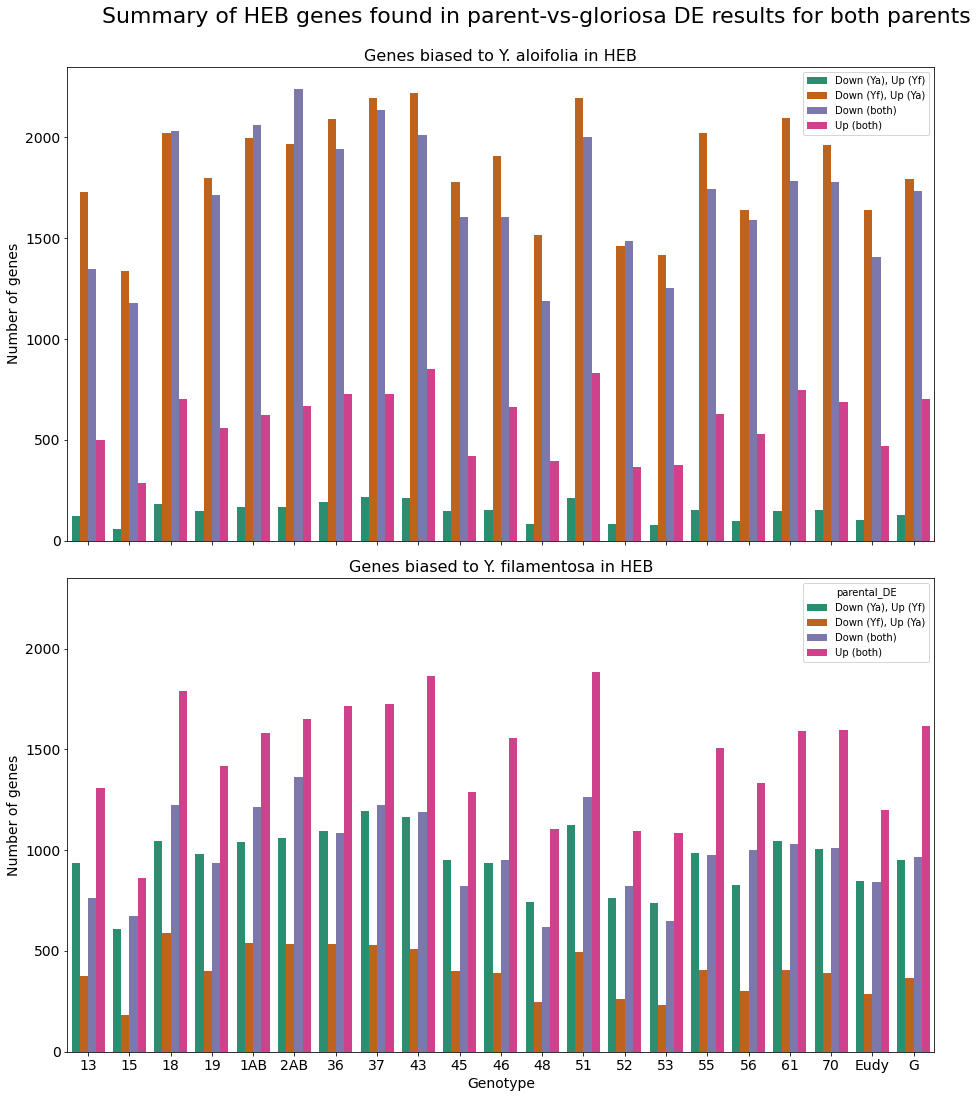

In [102]:
# plot
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(15,16),sharey=True,sharex=True)

sns.barplot(ax=ax[0],data=bothsum[bothsum["subgenome_bias"]=="Ya"],x="Genotype",y="n_genes",hue="parental_DE",palette="Dark2")
ax[0].legend(bbox_to_anchor=(1,1))
ax[0].set_title("Genes biased to Y. aloifolia in HEB",fontsize=16)
ax[0].set_ylabel("Number of genes",fontsize=14)
ax[0].tick_params(axis="both",labelsize=14)
ax[0].set_xlabel("")

sns.barplot(ax=ax[1],data=bothsum[bothsum["subgenome_bias"]=="Yf"],x="Genotype",y="n_genes",hue="parental_DE",palette="Dark2")
ax[1].set_title("Genes biased to Y. filamentosa in HEB",fontsize=16)
ax[1].set_ylabel("Number of genes",fontsize=14)
ax[1].tick_params(axis="both",labelsize=14)
ax[1].set_xlabel("Genotype",fontsize=14)

plt.suptitle("Summary of HEB genes found in parent-vs-gloriosa DE results for both parents",fontsize=22)
fig.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.savefig("./summary_bothparentalde_heb_detypes.png",dpi=200,bbox_inches="tight")
plt.savefig("./summary_bothparentalde_heb_detypes.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./summary_bothparentalde_heb_detypes.svg",dpi=200,bbox_inches="tight")

## How do CAM genes look in all of these summary categories?

In [109]:
yacamde = yadegs.merge(cam)[["GeneID","reg","Genotype","gene_abbr","gene_abbr_unique","subgenome"]]
yacamde.head()

,GeneID,reg,Genotype,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G077800.v2.1,Up,18,PPPC,Ya_PPPC_1,Ya
1,Yucal.01G077800.v2.1,Down,Eudy,PPPC,Ya_PPPC_1,Ya
2,Yucal.01G077800.v2.1,Down,56,PPPC,Ya_PPPC_1,Ya
3,Yucal.01G077800.v2.1,Down,43,PPPC,Ya_PPPC_1,Ya
4,Yucal.01G077800.v2.1,Down,48,PPPC,Ya_PPPC_1,Ya


In [110]:
yfcamde = yfdegs.merge(cam)[["GeneID","reg","Genotype","gene_abbr","gene_abbr_unique","subgenome"]]
yfcamde.head()

,GeneID,reg,Genotype,gene_abbr,gene_abbr_unique,subgenome
0,YufilH1001781m.g,Down,18,PPPC,Yf_PPPC_1,Yf
1,YufilH1001781m.g,Down,2AB,PPPC,Yf_PPPC_1,Yf
2,YufilH1001781m.g,Down,1AB,PPPC,Yf_PPPC_1,Yf
3,YufilH1001781m.g,Down,19,PPPC,Yf_PPPC_1,Yf
4,YufilH1001781m.g,Down,15,PPPC,Yf_PPPC_1,Yf


In [114]:
# make summaries (start for CAM genes overall)
yacamsum = yacamde.groupby(["Genotype","reg"]).count()["GeneID"].reset_index().rename(columns={"GeneID":"n_genes"})
yacamsum["sp"] = "aloifolia"
yacamsum.head()

,Genotype,reg,n_genes,sp
0,12,Down,10,aloifolia
1,12,Up,9,aloifolia
2,13,Down,16,aloifolia
3,13,Up,7,aloifolia
4,15,Down,15,aloifolia


In [115]:
yfcamsum = yfcamde.groupby(["Genotype","reg"]).count()["GeneID"].reset_index().rename(columns={"GeneID":"n_genes"})
yfcamsum["sp"] = "filamentosa"

In [116]:
allcamsum = pd.concat([yacamsum,yfcamsum])
allcamsum["parental_de"] = allcamsum["sp"]+"_"+allcamsum["reg"]
allcamsum.head()

,Genotype,reg,n_genes,sp,parental_de
0,12,Down,10,aloifolia,aloifolia_Down
1,12,Up,9,aloifolia,aloifolia_Up
2,13,Down,16,aloifolia,aloifolia_Down
3,13,Up,7,aloifolia,aloifolia_Up
4,15,Down,15,aloifolia,aloifolia_Down


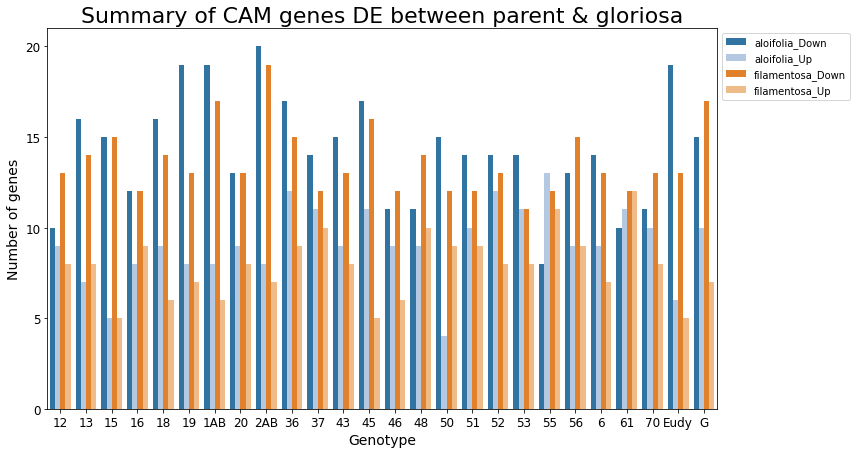

In [126]:
# plot
fig,ax = plt.subplots(figsize=(12,7))

sns.barplot(data=allcamsum,x="Genotype",y="n_genes",hue="parental_de",palette="tab20")
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel("Number of genes",fontsize=14)
plt.xticks(fontsize=12)
plt.xlabel("Genotype",fontsize=14)
plt.yticks(np.arange(0,21,5),fontsize=12)
plt.title("Summary of CAM genes DE between parent & gloriosa",fontsize=22)

plt.savefig("./parent-v-Yg_DE_CAMgenes_bygt_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./parent-v-Yg_DE_CAMgenes_bygt_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./parent-v-Yg_DE_CAMgenes_bygt_summary.svg",dpi=200,bbox_inches="tight")

In [131]:
# look at CAM gene pairs in HEB results
## to do this load long synteny file
syn = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",header="infer")
syn.head()

,GeneID,syntelogID
0,YufilH1000002m.g,recip_syn1
1,Yucal.01G000100.v2.1,recip_syn1
2,YufilH1000007m.g,recip_syn2
3,Yucal.01G000200.v2.1,recip_syn2
4,YufilH1000011m.g,recip_syn3


In [134]:
# merge with CAM annotation
camrsyn = cam.merge(syn)

In [135]:
camrsyn.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,recip_syn3628
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,recip_syn7619
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya,recip_syn13926
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya,recip_syn6335


In [136]:
heb.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,subgenome_bias
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,Yf
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,Yf
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,Yf
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,19,Yf
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,15,Yf


In [137]:
camheb = heb[["syntelogID","Yf_GeneID","Ya_GeneID","genotype","subgenome_bias"]].merge(camrsyn[["syntelogID","gene_abbr"]])
camheb.head()

,syntelogID,Yf_GeneID,Ya_GeneID,genotype,subgenome_bias,gene_abbr
0,recip_syn679,YufilH1001781m.g,Yucal.01G077800.v2.1,18,Yf,PPPC
1,recip_syn679,YufilH1001781m.g,Yucal.01G077800.v2.1,18,Yf,PPPC
2,recip_syn679,YufilH1001781m.g,Yucal.01G077800.v2.1,2AB,Yf,PPPC
3,recip_syn679,YufilH1001781m.g,Yucal.01G077800.v2.1,2AB,Yf,PPPC
4,recip_syn679,YufilH1001781m.g,Yucal.01G077800.v2.1,1AB,Yf,PPPC


In [138]:
both_degs_heb.head()

,Yf_GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Yf,Ya_GeneID,DE_v_Ya,parental_DE
0,YufilH1000007m.g,2AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down,Down (both)
1,YufilH1000007m.g,1AB,Yf,recip_syn2,Down,Yucal.01G000200.v2.1,Down,Down (both)
2,YufilH1000007m.g,19,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"
3,YufilH1000007m.g,Eudy,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"
4,YufilH1000007m.g,56,Yf,recip_syn2,Up,Yucal.01G000200.v2.1,Down,"Down (Ya), Up (Yf)"


In [139]:
# merge with both_degs_heb
both_deheb_cam = both_degs_heb.merge(camheb)
both_deheb_cam.head()

,Yf_GeneID,Genotype,subgenome_bias,syntelogID,DE_v_Yf,Ya_GeneID,DE_v_Ya,parental_DE,genotype,gene_abbr
0,YufilH1001781m.g,18,Yf,recip_syn679,Down,Yucal.01G077800.v2.1,Up,"Down (Yf), Up (Ya)",18,PPPC
1,YufilH1001781m.g,18,Yf,recip_syn679,Down,Yucal.01G077800.v2.1,Up,"Down (Yf), Up (Ya)",18,PPPC
2,YufilH1001781m.g,18,Yf,recip_syn679,Down,Yucal.01G077800.v2.1,Up,"Down (Yf), Up (Ya)",2AB,PPPC
3,YufilH1001781m.g,18,Yf,recip_syn679,Down,Yucal.01G077800.v2.1,Up,"Down (Yf), Up (Ya)",2AB,PPPC
4,YufilH1001781m.g,18,Yf,recip_syn679,Down,Yucal.01G077800.v2.1,Up,"Down (Yf), Up (Ya)",1AB,PPPC


In [143]:
both_deheb_cam.drop_duplicates(inplace=True)

In [145]:
# summarize
bcamsum = both_deheb_cam.groupby(["Genotype","subgenome_bias","parental_DE"]).count()["syntelogID"].reset_index().rename(columns={"syntelogID":"n_genes"})
bcamsum.head()

,Genotype,subgenome_bias,parental_DE,n_genes
0,13,Ya,"Down (Ya), Up (Yf)",21
1,13,Ya,"Down (Yf), Up (Ya)",25
2,13,Ya,Down (both),94
3,13,Yf,"Down (Ya), Up (Yf)",19
4,13,Yf,Up (both),21


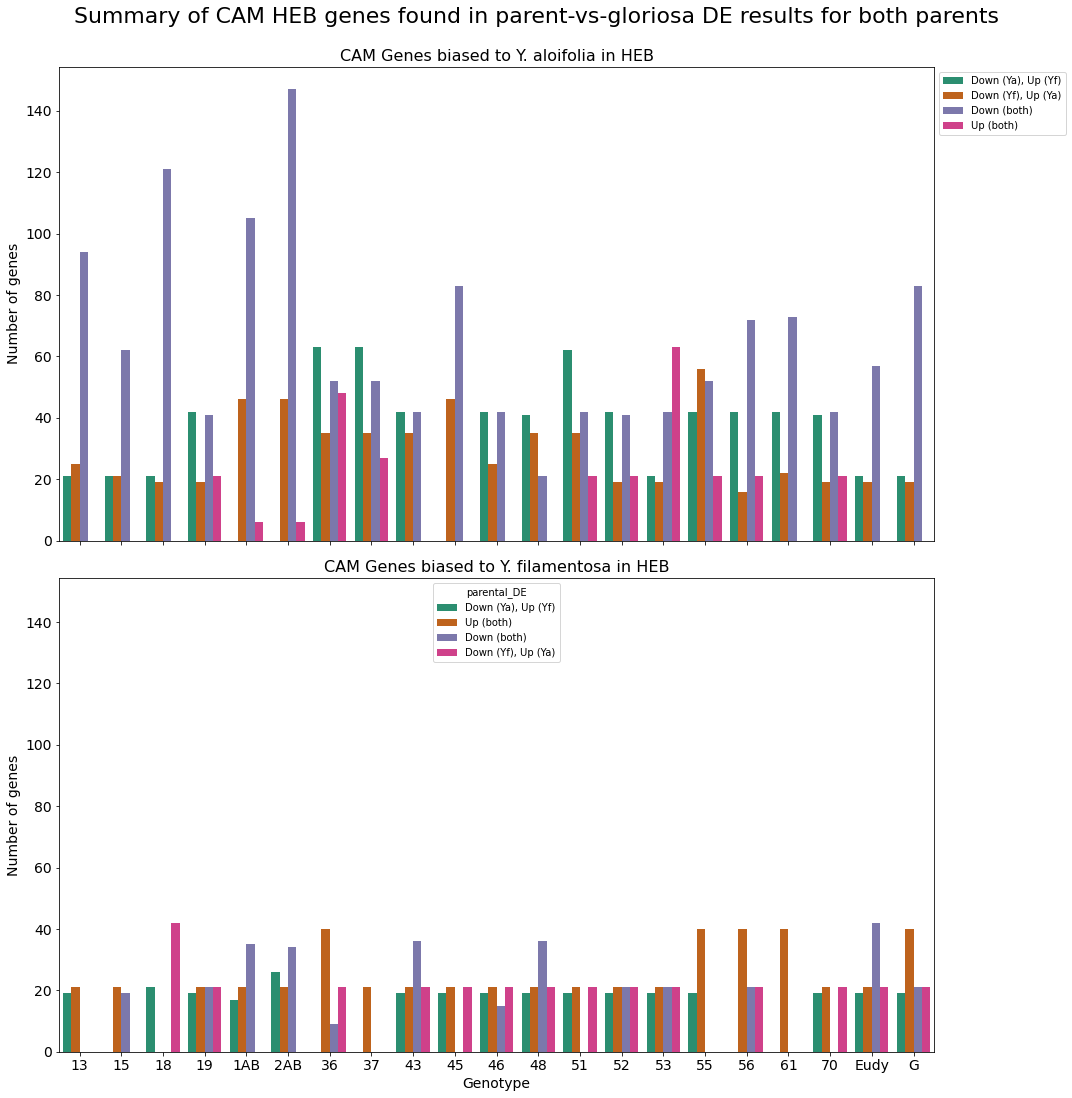

In [146]:
# plot as before
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(15,16),sharey=True,sharex=True)

sns.barplot(ax=ax[0],data=bcamsum[bcamsum["subgenome_bias"]=="Ya"],x="Genotype",y="n_genes",hue="parental_DE",palette="Dark2")
ax[0].legend(bbox_to_anchor=(1,1))
ax[0].set_title("CAM Genes biased to Y. aloifolia in HEB",fontsize=16)
ax[0].set_ylabel("Number of genes",fontsize=14)
ax[0].tick_params(axis="both",labelsize=14)
ax[0].set_xlabel("")

sns.barplot(ax=ax[1],data=bcamsum[bcamsum["subgenome_bias"]=="Yf"],x="Genotype",y="n_genes",hue="parental_DE",palette="Dark2")
ax[1].set_title("CAM Genes biased to Y. filamentosa in HEB",fontsize=16)
ax[1].set_ylabel("Number of genes",fontsize=14)
ax[1].tick_params(axis="both",labelsize=14)
ax[1].set_xlabel("Genotype",fontsize=14)

plt.suptitle("Summary of CAM HEB genes found in parent-vs-gloriosa DE results for both parents",fontsize=22)
fig.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.savefig("./summary_cam_bothparentalde_heb_detypes.png",dpi=200,bbox_inches="tight")
plt.savefig("./summary_cam_bothparentalde_heb_detypes.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./summary_cam_bothparentalde_heb_detypes.svg",dpi=200,bbox_inches="tight")

### Pull out lists of likely cis- & trans-regulated genes
- HEB only = cis only
- Opposite parental DE = trans only
- Same-direction parental DE = trans only, with additive effects?
- HEB + opposite parental DE = cis+trans
- HEB + same-direction parental DE = cis + trans + additive (?)


In [149]:
# write output json of HEB only genes for each genotype-bias combination
yadegs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,reg,Genotype
0,599.768106,0.277119,0.068780,4.029050,5.600264e-05,1.490326e-04,Yucal.01G000100.v2.1,aloifolia-V-18,Up,18
1,62.040930,-0.560176,0.064631,-8.667243,4.427109e-18,3.940780e-17,Yucal.01G000200.v2.1,aloifolia-V-18,Down,18
2,87.607801,-0.299740,0.060856,-4.925414,8.418210e-07,2.823562e-06,Yucal.01G000600.v2.1,aloifolia-V-18,Down,18
3,55.677109,-0.249716,0.077282,-3.231231,1.232584e-03,2.690041e-03,Yucal.01G000700.v2.1,aloifolia-V-18,Down,18
4,194.610942,0.313781,0.061659,5.088986,3.599837e-07,1.262833e-06,Yucal.01G000900.v2.1,aloifolia-V-18,Up,18


In [152]:
yfdegs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast,reg,Genotype
0,553.558614,0.626871,0.056978,11.001887,3.742183e-28,3.230509e-27,YufilH1000003m.g,filamentosa-V-18,Up,18
1,174.668434,0.285196,0.045355,6.288100,3.213759e-10,1.060107e-09,YufilH1000011m.g,filamentosa-V-18,Up,18
2,37.437113,-0.484818,0.072377,-6.698490,2.105847e-11,7.531972e-11,YufilH1000018m.g,filamentosa-V-18,Down,18
3,333.372693,-0.172390,0.053863,-3.200525,1.371776e-03,2.492578e-03,YufilH1000022m.g,filamentosa-V-18,Down,18
4,0.411826,2.444404,0.509699,4.795777,1.620459e-06,3.963539e-06,YufilH1000024m.g,filamentosa-V-18,Up,18


In [153]:
heb.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,subgenome_bias
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,Yf
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,Yf
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,Yf
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,19,Yf
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,15,Yf


In [159]:
def genotype_cis_genes(gt):
    gtde_ya = yadegs[yadegs["Genotype"]==gt]
    gtde_yf = yfdegs[yfdegs["Genotype"]==gt]
    d = {"Ya":gtde_ya,"Yf":gtde_yf}
    
    gtheb = heb[heb["genotype"]==gt]
    
    outdict = {}
    for i in ["Ya","Yf"]:
        if i=="Ya":
            alt="Yf"
        else:
            alt="Ya"
        df = gtheb[gtheb["subgenome_bias"]==i]
        dfsub = df[~df[i+"_GeneID"].isin(list(d[i]["GeneID"].unique()))]
        dfsub = dfsub[~dfsub[alt+"_GeneID"].isin(list(d[alt]["GeneID"].unique()))]
        outdict[i+"_biased"] = list(dfsub[i+"_GeneID"].unique())
    return outdict

In [162]:
cisgenes = {}
for g in heb["genotype"].unique():
    cisgenes[g] = genotype_cis_genes(g)

In [164]:
with open("./cisgenes_bygtbias.json","w+") as outfile:
    json.dump(cisgenes,outfile)